# Vilar Sloppy Complexity: Complexity vs Sloppiness for the Vilar Genetic Oscillator

Applies the same framework as TysonSloppyComplexity to the **Vilar et al. (2002)** noise-resistant genetic oscillator.

**Model:** 9 ODEs (DA, DA', DR, DR', MA, MR, A, R, C), 15 kinetic parameters.

**Approach:**
1. Sample parameters (Chico-style multiplicative perturbations)
2. Simulate, coarse-grain the **A:R Complex (C)** signal, compute CLZ complexity
3. Compute the Hessian of the cost function via sensitivity ODEs (analytic Jacobian)
4. Analyze eigenvalue spectrum → sloppiness vs complexity

In [16]:
import os
import math
import time
import random
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import warnings
from numpy.linalg import eigh

warnings.filterwarnings('ignore')

print("VilarSloppyComplexity: sampling complexity vs sloppiness")

VilarSloppyComplexity: sampling complexity vs sloppiness


In [17]:
# === CONFIGURATION ===
N_SAMPLES = int(1e2)             # Number of parameter samples
RANDOM_SEED = 123

# Complexity settings
SIM_TIME = 120.0              # Duration for complexity simulation (hours)
SIM_POINTS = 1001            # Points in simulation
COARSE_BINS = 50             # Bins for coarse-graining
DIVERGENCE_THRESHOLD = 1e6   # Threshold for detecting divergence

# Sloppiness settings (Hessian eigenvalue analysis)
T_FINAL = 30.0               # Duration for sloppiness analysis (hours)
N_TIME_POINTS = 1001         # Time points for sensitivity integration
STIFF_THRESHOLD = 1e-3       # Threshold to consider eigenvalue as \"stiff\" (not sloppy)

# Parameter sampling multipliers (Chico-style approach)
MULTIPLIERS = [0.25, 0.50, 0.75, 1.00, 1.25, 1.50, 1.75, 2.00]

# Observable: index into state vector [DA, DAp, DR, DRp, MA, MR, A, R, C]
OBSERVABLE_IDX = 8  # C (A:R Complex) - the inactive complex
OBSERVABLE_NAME = 'C (A:R Complex)'

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

print(f"Configuration:")
print(f"  N_SAMPLES: {N_SAMPLES}")
print(f"  SIM_TIME: {SIM_TIME} h, COARSE_BINS: {COARSE_BINS}")
print(f"  STIFF_THRESHOLD: {STIFF_THRESHOLD:.0e}")
print(f"  MULTIPLIERS: {MULTIPLIERS}")
print(f"  Observable: {OBSERVABLE_NAME} (index {OBSERVABLE_IDX})")

Configuration:
  N_SAMPLES: 100
  SIM_TIME: 120.0 h, COARSE_BINS: 50
  STIFF_THRESHOLD: 1e-03
  MULTIPLIERS: [0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]
  Observable: R (Repressor) (index 7)


In [18]:
# === VILAR MODEL DEFINITION ===
# Vilar et al. (2002) PNAS 99(9):5988-5992
# Noise-resistant genetic oscillator
#
# States: [DA, DAp, DR, DRp, MA, MR, A, R, C]
#   DA  = Activator gene, promoter free
#   DAp = Activator gene, A bound to promoter
#   DR  = Repressor gene, promoter free
#   DRp = Repressor gene, A bound to promoter
#   MA  = Activator mRNA
#   MR  = Repressor mRNA
#   A   = Free Activator protein
#   R   = Free Repressor protein
#   C   = Inactive A:R complex
#
# Conservation laws: DA + DAp = 1, DR + DRp = 1
# (kept as explicit ODEs for generality)

# Default parameters from BioModels BIOMD0000000035
p_default = {
    'alphaA':   50.0,    # h^-1, basal transcription of A gene
    'alphaAp': 500.0,    # h^-1, activated transcription of A gene
    'alphaR':    0.01,   # h^-1, basal transcription of R gene
    'alphaRp':  50.0,    # h^-1, activated transcription of R gene
    'betaA':    50.0,    # h^-1, A translation rate
    'betaR':     5.0,    # h^-1, R translation rate
    'deltaMA':  10.0,    # h^-1, A mRNA degradation
    'deltaMR':   0.5,    # h^-1, R mRNA degradation
    'deltaA':    1.0,    # h^-1, A protein degradation (& complex C degradation)
    'deltaR':    0.2,    # h^-1, R protein degradation
    'gammaA':    1.0,    # mol^-1 h^-1, A binding to A-promoter
    'gammaR':    1.0,    # mol^-1 h^-1, A binding to R-promoter
    'gammaC':    2.0,    # mol^-1 h^-1, A:R complex formation rate
    'thetaA':   50.0,    # h^-1, A unbinding from A-promoter
    'thetaR':  100.0,    # h^-1, A unbinding from R-promoter
}

# All 15 parameters are varied
param_names = list(p_default.keys())
P = len(param_names)
p_index = {name: i for i, name in enumerate(param_names)}

# State indices for readability
iDA, iDAp, iDR, iDRp, iMA, iMR, iA, iR, iC = range(9)
N_STATES = 9

# Initial conditions: gene promoters free, everything else zero
y0 = np.array([1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0])

print(f"\nVilar Model: {N_STATES} states, {P} kinetic parameters")
print(f"States: DA, DAp, DR, DRp, MA, MR, A, R, C")
print(f"Parameters: {param_names}")


Vilar Model: 9 states, 15 kinetic parameters
States: DA, DAp, DR, DRp, MA, MR, A, R, C
Parameters: ['alphaA', 'alphaAp', 'alphaR', 'alphaRp', 'betaA', 'betaR', 'deltaMA', 'deltaMR', 'deltaA', 'deltaR', 'gammaA', 'gammaR', 'gammaC', 'thetaA', 'thetaR']


In [19]:
# === VILAR MODEL DYNAMICS ===

def f_rhs(t, x, p):
    """Right-hand side of Vilar model ODEs
    x = [DA, DAp, DR, DRp, MA, MR, A, R, C]
    """
    DA, DAp, DR, DRp, MA, MR, A, R, C = x
    
    dDA  = -p['gammaA'] * A * DA  + p['thetaA'] * DAp
    dDAp =  p['gammaA'] * A * DA  - p['thetaA'] * DAp
    dDR  = -p['gammaR'] * A * DR  + p['thetaR'] * DRp
    dDRp =  p['gammaR'] * A * DR  - p['thetaR'] * DRp
    dMA  =  p['alphaA'] * DA + p['alphaAp'] * DAp - p['deltaMA'] * MA
    dMR  =  p['alphaR'] * DR + p['alphaRp'] * DRp - p['deltaMR'] * MR
    dA   =  p['betaA'] * MA - p['deltaA'] * A - p['gammaC'] * A * R \
           - p['gammaA'] * A * DA + p['thetaA'] * DAp \
           - p['gammaR'] * A * DR + p['thetaR'] * DRp
    dR   =  p['betaR'] * MR - p['deltaR'] * R - p['gammaC'] * A * R + p['deltaA'] * C
    dC   =  p['gammaC'] * A * R - p['deltaA'] * C
    
    return np.array([dDA, dDAp, dDR, dDRp, dMA, dMR, dA, dR, dC])


def jacobian_fx(x, p):
    """Compute df/dx (9x9 Jacobian) analytically at state x
    
    State ordering: [DA, DAp, DR, DRp, MA, MR, A, R, C]
    Indices:         0    1    2    3    4   5   6  7  8
    """
    DA, DAp, DR, DRp, MA, MR, A, R, C = x
    
    J = np.zeros((N_STATES, N_STATES))
    
    # dDA/d... = -gammaA*A*DA + thetaA*DAp
    J[0, 0] = -p['gammaA'] * A          # d(dDA)/dDA
    J[0, 1] =  p['thetaA']              # d(dDA)/dDAp
    J[0, 6] = -p['gammaA'] * DA          # d(dDA)/dA
    
    # dDAp/d... = gammaA*A*DA - thetaA*DAp
    J[1, 0] =  p['gammaA'] * A          # d(dDAp)/dDA
    J[1, 1] = -p['thetaA']              # d(dDAp)/dDAp
    J[1, 6] =  p['gammaA'] * DA          # d(dDAp)/dA
    
    # dDR/d... = -gammaR*A*DR + thetaR*DRp
    J[2, 2] = -p['gammaR'] * A          # d(dDR)/dDR
    J[2, 3] =  p['thetaR']              # d(dDR)/dDRp
    J[2, 6] = -p['gammaR'] * DR          # d(dDR)/dA
    
    # dDRp/d... = gammaR*A*DR - thetaR*DRp
    J[3, 2] =  p['gammaR'] * A          # d(dDRp)/dDR
    J[3, 3] = -p['thetaR']              # d(dDRp)/dDRp
    J[3, 6] =  p['gammaR'] * DR          # d(dDRp)/dA
    
    # dMA/d... = alphaA*DA + alphaAp*DAp - deltaMA*MA
    J[4, 0] =  p['alphaA']              # d(dMA)/dDA
    J[4, 1] =  p['alphaAp']             # d(dMA)/dDAp
    J[4, 4] = -p['deltaMA']             # d(dMA)/dMA
    
    # dMR/d... = alphaR*DR + alphaRp*DRp - deltaMR*MR
    J[5, 2] =  p['alphaR']              # d(dMR)/dDR
    J[5, 3] =  p['alphaRp']             # d(dMR)/dDRp
    J[5, 5] = -p['deltaMR']             # d(dMR)/dMR
    
    # dA/d... = betaA*MA - deltaA*A - gammaC*A*R
    #         - gammaA*A*DA + thetaA*DAp - gammaR*A*DR + thetaR*DRp
    J[6, 0] = -p['gammaA'] * A          # d(dA)/dDA
    J[6, 1] =  p['thetaA']              # d(dA)/dDAp
    J[6, 2] = -p['gammaR'] * A          # d(dA)/dDR
    J[6, 3] =  p['thetaR']              # d(dA)/dDRp
    J[6, 4] =  p['betaA']               # d(dA)/dMA
    J[6, 6] = -p['deltaA'] - p['gammaC'] * R \
              - p['gammaA'] * DA - p['gammaR'] * DR  # d(dA)/dA
    J[6, 7] = -p['gammaC'] * A          # d(dA)/dR
    
    # dR/d... = betaR*MR - deltaR*R - gammaC*A*R + deltaA*C
    J[7, 5] =  p['betaR']               # d(dR)/dMR
    J[7, 6] = -p['gammaC'] * R          # d(dR)/dA
    J[7, 7] = -p['deltaR'] - p['gammaC'] * A  # d(dR)/dR
    J[7, 8] =  p['deltaA']              # d(dR)/dC
    
    # dC/d... = gammaC*A*R - deltaA*C
    J[8, 6] =  p['gammaC'] * R          # d(dC)/dA
    J[8, 7] =  p['gammaC'] * A          # d(dC)/dR
    J[8, 8] = -p['deltaA']              # d(dC)/dC
    
    return J


def df_dparam(x, p):
    """Compute df/dh for each parameter (returns 9 x P array)
    where h are the parameters in param_names.
    
    Each column j gives the 9-vector d(f)/d(param_names[j]).
    """
    DA, DAp, DR, DRp, MA, MR, A, R, C = x
    
    dfdh = np.zeros((N_STATES, P))
    
    # alphaA: appears in dMA = alphaA*DA + ...
    j = p_index['alphaA']
    dfdh[iMA, j] = DA
    
    # alphaAp: appears in dMA = ... + alphaAp*DAp + ...
    j = p_index['alphaAp']
    dfdh[iMA, j] = DAp
    
    # alphaR: appears in dMR = alphaR*DR + ...
    j = p_index['alphaR']
    dfdh[iMR, j] = DR
    
    # alphaRp: appears in dMR = ... + alphaRp*DRp + ...
    j = p_index['alphaRp']
    dfdh[iMR, j] = DRp
    
    # betaA: appears in dA = betaA*MA + ...
    j = p_index['betaA']
    dfdh[iA, j] = MA
    
    # betaR: appears in dR = betaR*MR + ...
    j = p_index['betaR']
    dfdh[iR, j] = MR
    
    # deltaMA: appears in dMA = ... - deltaMA*MA
    j = p_index['deltaMA']
    dfdh[iMA, j] = -MA
    
    # deltaMR: appears in dMR = ... - deltaMR*MR
    j = p_index['deltaMR']
    dfdh[iMR, j] = -MR
    
    # deltaA: appears in dA = ... - deltaA*A ...
    #         appears in dR = ... + deltaA*C
    #         appears in dC = ... - deltaA*C
    j = p_index['deltaA']
    dfdh[iA, j] = -A
    dfdh[iR, j] =  C
    dfdh[iC, j] = -C
    
    # deltaR: appears in dR = ... - deltaR*R ...
    j = p_index['deltaR']
    dfdh[iR, j] = -R
    
    # gammaA: appears in dDA  = -gammaA*A*DA + ...
    #         appears in dDAp =  gammaA*A*DA - ...
    #         appears in dA   = ... - gammaA*A*DA + ...
    j = p_index['gammaA']
    dfdh[iDA,  j] = -A * DA
    dfdh[iDAp, j] =  A * DA
    dfdh[iA,   j] = -A * DA
    
    # gammaR: appears in dDR  = -gammaR*A*DR + ...
    #         appears in dDRp =  gammaR*A*DR - ...
    #         appears in dA   = ... - gammaR*A*DR + ...
    j = p_index['gammaR']
    dfdh[iDR,  j] = -A * DR
    dfdh[iDRp, j] =  A * DR
    dfdh[iA,   j] = -A * DR
    
    # gammaC: appears in dA = ... - gammaC*A*R ...
    #         appears in dR = ... - gammaC*A*R ...
    #         appears in dC =  gammaC*A*R - ...
    j = p_index['gammaC']
    dfdh[iA, j] = -A * R
    dfdh[iR, j] = -A * R
    dfdh[iC, j] =  A * R
    
    # thetaA: appears in dDA  = ... + thetaA*DAp
    #         appears in dDAp = ... - thetaA*DAp
    #         appears in dA   = ... + thetaA*DAp ...
    j = p_index['thetaA']
    dfdh[iDA,  j] =  DAp
    dfdh[iDAp, j] = -DAp
    dfdh[iA,   j] =  DAp
    
    # thetaR: appears in dDR  = ... + thetaR*DRp
    #         appears in dDRp = ... - thetaR*DRp
    #         appears in dA   = ... + thetaR*DRp
    j = p_index['thetaR']
    dfdh[iDR,  j] =  DRp
    dfdh[iDRp, j] = -DRp
    dfdh[iA,   j] =  DRp
    
    return dfdh


print("Vilar model dynamics, Jacobian (9x9), and parameter sensitivities (9x15) defined")

Vilar model dynamics, Jacobian (9x9), and parameter sensitivities (9x15) defined


In [20]:
# === VERIFY JACOBIAN WITH FINITE DIFFERENCES ===

def verify_jacobian(p, x_test, eps=1e-7):
    """Compare analytic Jacobian with finite-difference approximation"""
    J_analytic = jacobian_fx(x_test, p)
    
    J_fd = np.zeros((N_STATES, N_STATES))
    f0 = f_rhs(0, x_test, p)
    for j in range(N_STATES):
        x_pert = x_test.copy()
        x_pert[j] += eps
        f_pert = f_rhs(0, x_pert, p)
        J_fd[:, j] = (f_pert - f0) / eps
    
    max_err = np.max(np.abs(J_analytic - J_fd))
    rel_err = max_err / (np.max(np.abs(J_fd)) + 1e-30)
    return max_err, rel_err

def verify_df_dparam(p, x_test, eps=1e-7):
    """Compare analytic df/dparam with finite-difference approximation"""
    dfdh_analytic = df_dparam(x_test, p)
    
    dfdh_fd = np.zeros((N_STATES, P))
    f0 = f_rhs(0, x_test, p)
    for j, name in enumerate(param_names):
        p_pert = dict(p)
        p_pert[name] += eps
        f_pert = f_rhs(0, x_test, p_pert)
        dfdh_fd[:, j] = (f_pert - f0) / eps
    
    max_err = np.max(np.abs(dfdh_analytic - dfdh_fd))
    rel_err = max_err / (np.max(np.abs(dfdh_fd)) + 1e-30)
    return max_err, rel_err

# Test at a non-trivial state
x_test = np.array([0.5, 0.5, 0.6, 0.4, 10.0, 5.0, 100.0, 50.0, 20.0])

max_err_J, rel_err_J = verify_jacobian(p_default, x_test)
print(f"Jacobian df/dx verification:")
print(f"  Max absolute error: {max_err_J:.2e}")
print(f"  Max relative error: {rel_err_J:.2e}")
print(f"  {'PASS' if rel_err_J < 1e-5 else 'FAIL'}")

max_err_p, rel_err_p = verify_df_dparam(p_default, x_test)
print(f"\ndf/dparam verification:")
print(f"  Max absolute error: {max_err_p:.2e}")
print(f"  Max relative error: {rel_err_p:.2e}")
print(f"  {'PASS' if rel_err_p < 1e-5 else 'FAIL'}")

Jacobian df/dx verification:
  Max absolute error: 7.61e-06
  Max relative error: 1.52e-08
  PASS

df/dparam verification:
  Max absolute error: 1.72e-05
  Max relative error: 3.43e-09
  PASS


In [21]:
# === COMPLEXITY ANALYSIS FUNCTIONS ===

def sample_parameters(p_base, param_names, multipliers, wildtype=False):
    """Sample parameters by multiplying with random factors"""
    p_new = dict(p_base)
    sampled_factors = {}
    if wildtype:
        return p_new, sampled_factors
    for name in param_names:
        factor = random.choice(multipliers)
        p_new[name] = p_base[name] * factor
        sampled_factors[name] = factor
    return p_new, sampled_factors


def simulate_vilar(p, y0, t_span=(0, 30), n_points=1001):
    """Simulate the Vilar model"""
    try:
        sol = solve_ivp(
            lambda t, x: f_rhs(t, x, p),
            t_span,
            y0,
            method='BDF',
            t_eval=np.linspace(t_span[0], t_span[1], n_points),
            rtol=1e-8,
            atol=1e-10,
            max_step=0.1
        )
        if not sol.success:
            return None, None
        return sol.t, sol.y  # time, states (9 x n_points)
    except Exception:
        return None, None


def check_divergence(states, threshold=DIVERGENCE_THRESHOLD):
    """Check if any state variable diverges beyond threshold"""
    return np.any(np.abs(states) > threshold) or np.any(np.isnan(states))


def coarse_grain(time_arr, signal, nbins=COARSE_BINS):
    """Coarse-grain signal to nbins points"""
    coarse_time = np.linspace(time_arr[0], time_arr[-1], nbins)
    coarse_signal = np.interp(coarse_time, time_arr, signal)
    return coarse_time, coarse_signal


def up_down_encoding(coarse_time, coarse_signal):
    """Create binary up-down encoding from coarse-grained signal"""
    slopes = np.diff(coarse_signal) / np.diff(coarse_time)
    return ''.join(['1' if s > 0 else '0' for s in slopes])


def lz76_phrase_count(s):
    """Lempel-Ziv 76 phrase counting algorithm"""
    n = len(s)
    if n == 0:
        return 0
    i = 0; c = 1; k = 1
    while i + k <= n:
        if s[i:i+k] in s[:i+k-1]:
            k += 1
            if i + k - 1 > n:
                c += 1
                break
        else:
            c += 1
            i += k
            k = 1
    return c


def CLZ(x):
    """Symmetric Lempel-Ziv complexity"""
    n = len(x)
    if n == 0:
        return 0.0
    if x.count('0') == n or x.count('1') == n:
        return math.log2(n)
    return math.log2(n) / 2 * (lz76_phrase_count(x) + lz76_phrase_count(x[::-1]))


def compute_complexity(p, y0, observable_idx=OBSERVABLE_IDX):
    """Compute CLZ complexity of a Vilar trajectory"""
    t, states = simulate_vilar(p, y0, (0, SIM_TIME), SIM_POINTS)
    if t is None or states is None:
        return None
    if check_divergence(states, DIVERGENCE_THRESHOLD):
        return 'divergent'
    
    signal = states[observable_idx, :]
    coarse_time, coarse_signal = coarse_grain(t, signal, COARSE_BINS)
    encoding = up_down_encoding(coarse_time, coarse_signal)
    return CLZ(encoding)


print("Complexity analysis functions defined (CLZ on C dynamics)")

Complexity analysis functions defined (CLZ on C dynamics)


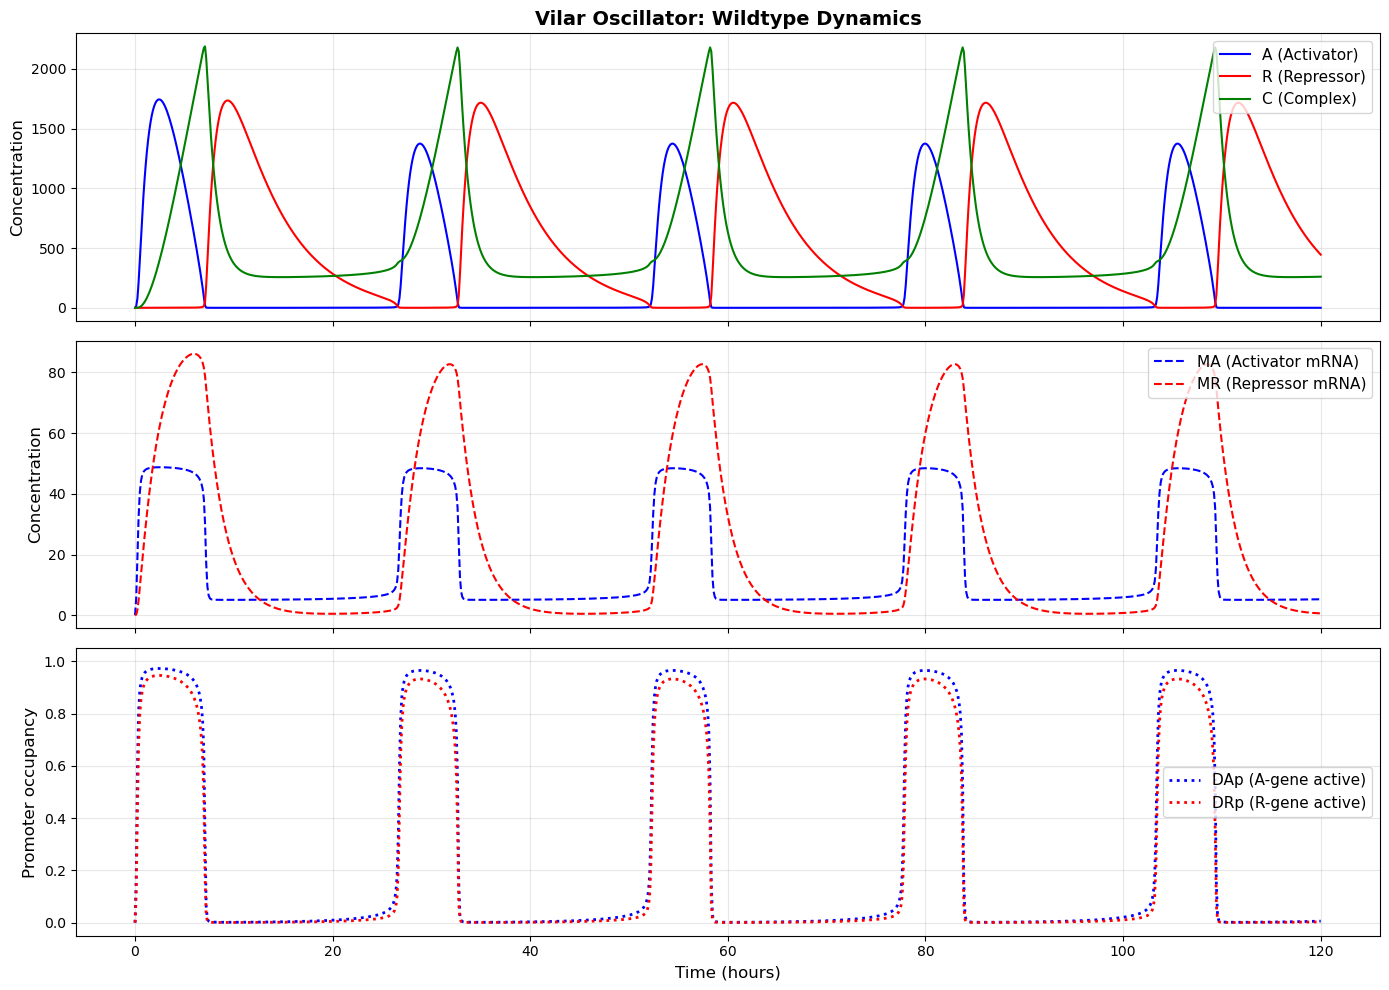


Wildtype complexity (CLZ on C): 39.303
C amplitude: 1716.30
A amplitude: 1374.73


In [22]:
# === TEST: WILDTYPE SIMULATION ===

t_test, states_test = simulate_vilar(p_default, y0, (0, SIM_TIME), SIM_POINTS)

if t_test is not None:
    fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
    
    # Activator A and Repressor R
    ax = axes[0]
    ax.plot(t_test, states_test[iA, :], 'b-', linewidth=1.5, label='A (Activator)')
    ax.plot(t_test, states_test[iR, :], 'r-', linewidth=1.5, label='R (Repressor)')
    ax.plot(t_test, states_test[iC, :], 'g-', linewidth=1.5, label='C (Complex)')
    ax.set_ylabel('Concentration', fontsize=12)
    ax.set_title('Vilar Oscillator: Wildtype Dynamics', fontsize=14, weight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # mRNAs
    ax = axes[1]
    ax.plot(t_test, states_test[iMA, :], 'b--', linewidth=1.5, label='MA (Activator mRNA)')
    ax.plot(t_test, states_test[iMR, :], 'r--', linewidth=1.5, label='MR (Repressor mRNA)')
    ax.set_ylabel('Concentration', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    
    # Gene states
    ax = axes[2]
    ax.plot(t_test, states_test[iDAp, :], 'b:', linewidth=2, label='DAp (A-gene active)')
    ax.plot(t_test, states_test[iDRp, :], 'r:', linewidth=2, label='DRp (R-gene active)')
    ax.set_ylabel('Promoter occupancy', fontsize=12)
    ax.set_xlabel('Time (hours)', fontsize=12)
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    ax.set_ylim([-0.05, 1.05])
    
    plt.tight_layout()
    plt.show()
    
    # Compute wildtype complexity
    wt_complexity = compute_complexity(p_default, y0)
    print(f"\nWildtype complexity (CLZ on C): {wt_complexity:.3f}")
    print(f"C amplitude: {states_test[iC, 100:].max() - states_test[iC, 100:].min():.2f}")
    print(f"A amplitude: {states_test[iA, 100:].max() - states_test[iA, 100:].min():.2f}")
else:
    print("Wildtype simulation failed!")

In [23]:
# === SLOPPINESS ANALYSIS (HESSIAN COMPUTATION VIA SENSITIVITY ODEs) ===

def augmented_rhs(t, z, p, param_names):
    """Augmented system for sensitivity analysis.
    z contains [x(9), S_flat(9*P)] where S_j = h_j * dx/dh_j (log-sensitivities)
    """
    x = z[:N_STATES]
    S_flat = z[N_STATES:]
    S = S_flat.reshape((N_STATES, P), order='F')  # columns are parameters
    
    # Base dynamics
    xdot = f_rhs(t, x, p)
    
    # Jacobians
    A = jacobian_fx(x, p)          # 9x9: df/dx
    df_dh = df_dparam(x, p)        # 9xP: df/dh
    
    # Convert df/dh to df/dlogh: df/dlogh_j = h_j * df/dh_j
    df_dlogh = np.zeros_like(df_dh)
    for j, name in enumerate(param_names):
        hj = p[name]
        df_dlogh[:, j] = hj * df_dh[:, j]
    
    # Sensitivity ODEs: dS/dt = A * S + df/dlogh
    Sdot = A.dot(S) + df_dlogh
    
    return np.concatenate([xdot, Sdot.ravel(order='F')])


def compute_hessian(p, param_names, y0, t_final=T_FINAL, n_points=N_TIME_POINTS):
    """Compute Hessian (Fisher Information Matrix) via sensitivity integration.
    
    Returns: H (P x P matrix) or None if simulation fails
    """
    # Initial sensitivities: zero (x0 independent of params)
    S0 = np.zeros((N_STATES, P))
    z0 = np.concatenate([y0, S0.ravel(order='F')])
    
    t_eval = np.linspace(0, t_final, n_points)
    
    try:
        sol_aug = solve_ivp(
            lambda t, z: augmented_rhs(t, z, p, param_names),
            (0, t_final),
            z0,
            method='BDF',
            t_eval=t_eval,
            rtol=1e-8,
            atol=1e-10,
            max_step=0.1
        )
        
        if not sol_aug.success:
            return None
        
        t = sol_aug.t
        m = t.size
        S_flat = sol_aug.y[N_STATES:, :]  # (9*P) x m
        
        # Reshape sensitivities
        S_time = np.zeros((N_STATES, P, m))
        for i in range(m):
            S_time[:, :, i] = S_flat[:, i].reshape((N_STATES, P), order='F')
        
        # Output sensitivities (identity observation function = all 9 states)
        J_time = S_time.copy()
        
        # Weighting
        Ns = N_STATES
        Nc = 1
        Tc = t_final
        sigma = 1.0
        W_diag = np.ones(Ns) * (1.0 / (Nc * Ns * Tc * sigma**2))
        W = np.diag(W_diag)
        
        # Quadrature weights (trapezoid)
        dt = np.diff(t)
        q = np.zeros(m)
        q[0] = dt[0] / 2.0
        q[-1] = dt[-1] / 2.0
        q[1:-1] = 0.5 * (dt[:-1] + dt[1:])
        
        # Accumulate Hessian: H = integral(J^T W J dt)
        H = np.zeros((P, P))
        for i in range(m):
            J_i = J_time[:, :, i]         # (9 x P)
            A_i = J_i.T.dot(W).dot(J_i)   # P x P
            H += q[i] * A_i
        
        return H
    
    except Exception:
        return None


def analyze_hessian(H, stiff_threshold=STIFF_THRESHOLD):
    """Analyze Hessian eigenspectrum.
    Returns: eigenvalues (descending), eigenvectors, stiff_count
    """
    if H is None:
        return None, None, 0
    eigvals, eigvecs = eigh(H)
    eigvals = eigvals[::-1]       # descending
    eigvecs = eigvecs[:, ::-1]
    stiff_count = np.sum(eigvals > stiff_threshold)
    return eigvals, eigvecs, stiff_count


print("Sloppiness analysis functions defined (full Hessian via sensitivity ODEs)")
print(f"Augmented system size: {N_STATES} + {N_STATES}*{P} = {N_STATES + N_STATES*P} ODEs")

Sloppiness analysis functions defined (full Hessian via sensitivity ODEs)
Augmented system size: 9 + 9*15 = 144 ODEs


In [ ]:
# === RUN SAMPLING: COMPLEXITY vs SLOPPINESS ===

results = []
failed_complexity = 0
failed_sloppiness = 0

timing_complexity = []
timing_hessian = []

start_time = time.time()

print(f"\nStarting sampling: {N_SAMPLES} samples + wildtype")
print("=" * 70)

# --- Wildtype analysis first ---
print("\n[WILDTYPE]")
p_wt = dict(p_default)

complexity_wt = compute_complexity(p_wt, y0)
if complexity_wt is None or isinstance(complexity_wt, str):
    print(f"  Complexity: FAILED ({complexity_wt})")
else:
    print(f"  Complexity: {complexity_wt:.3f}")
    H_wt = compute_hessian(p_wt, param_names, y0)
    if H_wt is None:
        print(f"  Sloppiness: FAILED")
    else:
        eigvals_wt, eigvecs_wt, stiff_count_wt = analyze_hessian(H_wt)
        print(f"  Stiff count (lambda > {STIFF_THRESHOLD:.0e}): {stiff_count_wt}/{P}")
        print(f"  Eigenvalue range: [{eigvals_wt[-1]:.2e}, {eigvals_wt[0]:.2e}]")
        results.append({
            'label': 'Wildtype',
            'complexity': complexity_wt,
            'stiff_count': stiff_count_wt,
            'eigenvalues': eigvals_wt,
            'params': p_wt
        })

# --- Random samples ---
for i in range(N_SAMPLES):
    p_sample, factors = sample_parameters(p_default, param_names, MULTIPLIERS, wildtype=False)
    
    # Complexity
    t_start_cmplx = time.time()
    complexity = compute_complexity(p_sample, y0)
    t_cmplx = time.time() - t_start_cmplx
    
    if complexity is None or isinstance(complexity, str):
        failed_complexity += 1
        continue
    timing_complexity.append(t_cmplx)
    
    # Sloppiness
    t_start_hess = time.time()
    H = compute_hessian(p_sample, param_names, y0)
    t_hess = time.time() - t_start_hess
    
    if H is None:
        failed_sloppiness += 1
        continue
    timing_hessian.append(t_hess)
    
    eigvals, eigvecs, stiff_count = analyze_hessian(H)
    
    results.append({
        'label': f'Sample {i+1}',
        'complexity': complexity,
        'stiff_count': stiff_count,
        'eigenvalues': eigvals,
        'params': p_sample
    })
    
    if (i + 1) % max(1, N_SAMPLES // 10) == 0:
        elapsed = time.time() - start_time
        valid = len(results)
        rate = (i + 1) / elapsed if elapsed > 0 else 0
        eta = (N_SAMPLES - (i + 1)) / rate if rate > 0 else 0
        print(f"Progress: {i+1}/{N_SAMPLES} ({100*(i+1)/N_SAMPLES:.1f}%) | "
              f"valid={valid} | failed_cmplx={failed_complexity} | failed_slop={failed_sloppiness} | "
              f"elapsed={elapsed:.1f}s | rate={rate:.2f}/s | ETA={eta:.1f}s")

elapsed_total = time.time() - start_time
print(f"\n{'='*70}")
print(f"COMPLETE: {len(results)} valid samples in {elapsed_total:.1f}s")
print(f"Failed - complexity: {failed_complexity}, sloppiness: {failed_sloppiness}")
print(f"{'='*70}")


Starting sampling: 100 samples + wildtype

[WILDTYPE]
  Complexity: 39.303
  Stiff count (lambda > 1e-03): 14/15
  Eigenvalue range: [9.55e-04, 3.88e+06]
Progress: 10/100 (10.0%) | valid=11 | failed_cmplx=0 | failed_slop=0 | elapsed=38.9s | rate=0.26/s | ETA=350.4s
Progress: 20/100 (20.0%) | valid=21 | failed_cmplx=0 | failed_slop=0 | elapsed=73.9s | rate=0.27/s | ETA=295.5s


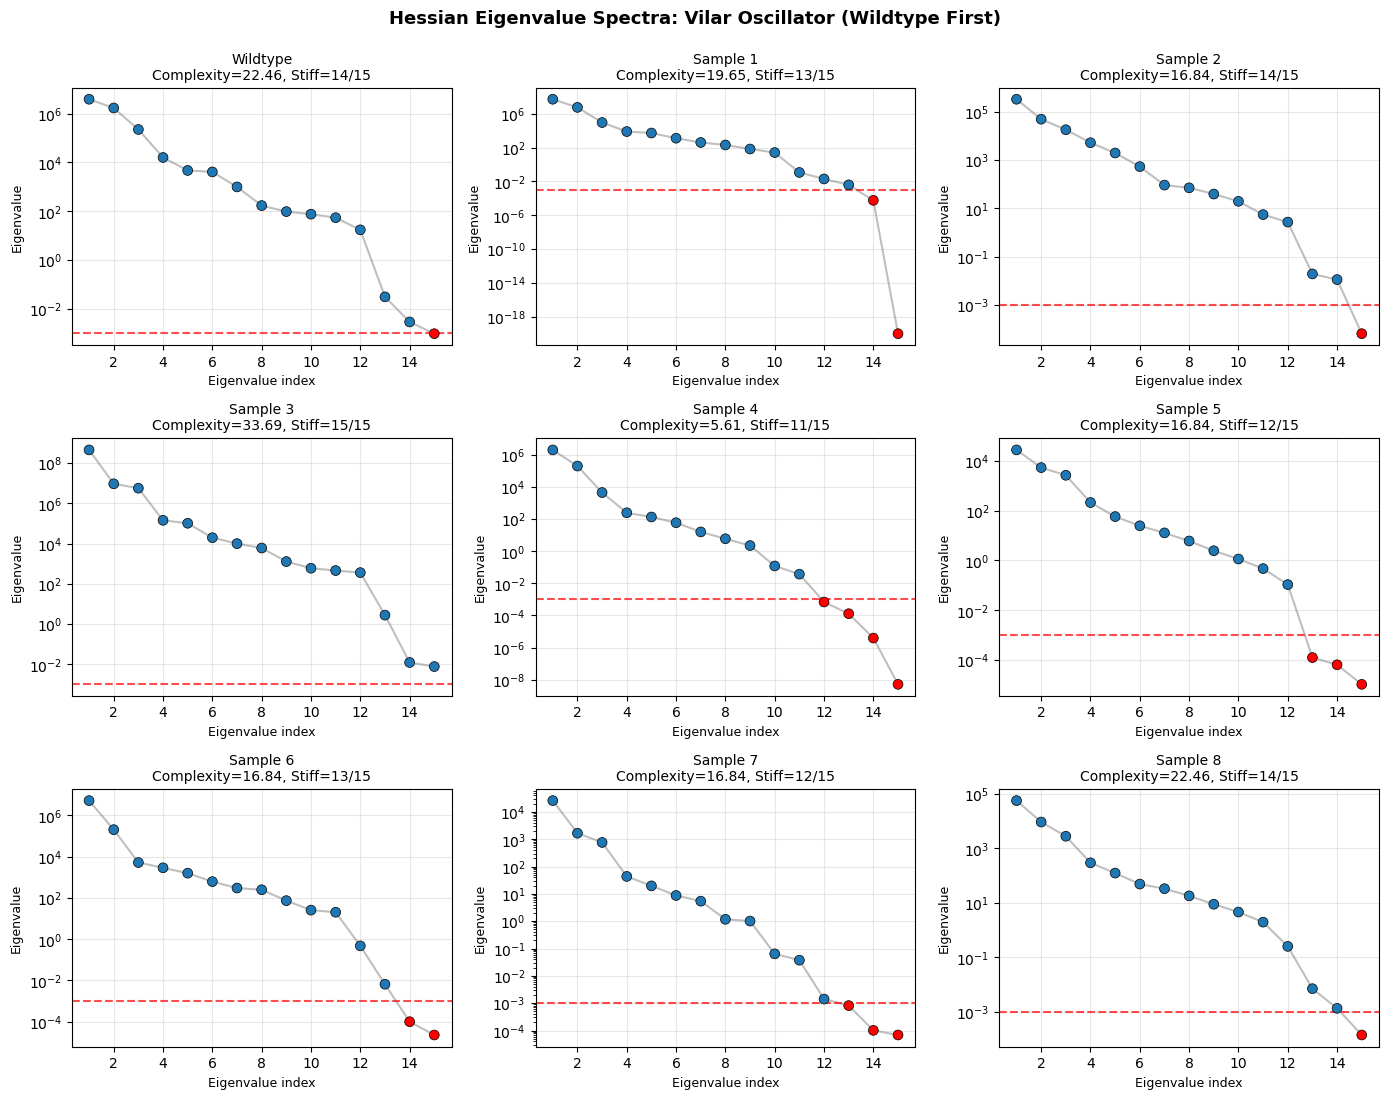

In [ ]:
# === VISUALIZATION: EIGENVALUE SPECTRA (FIRST 9 SAMPLES) ===

if len(results) == 0:
    print("No valid results to plot.")
else:
    n_show = min(9, len(results))
    fig, axes = plt.subplots(3, 3, figsize=(14, 11))
    axes = axes.flatten()
    
    for idx in range(n_show):
        entry = results[idx]
        eigenvals = np.asarray(entry['eigenvalues'])
        ax = axes[idx]
        
        x_ax = np.arange(1, len(eigenvals) + 1)
        colors = ['red' if ev < STIFF_THRESHOLD else 'C0' for ev in eigenvals]
        
        ax.semilogy(x_ax, np.maximum(eigenvals, 1e-20), 'o-', markersize=5,
                    linewidth=1.5, color='gray', alpha=0.5)
        ax.scatter(x_ax, np.maximum(eigenvals, 1e-20), c=colors, s=50,
                   zorder=3, edgecolors='black', linewidths=0.5)
        ax.axhline(STIFF_THRESHOLD, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        
        ax.set_title(f"{entry.get('label', f'Sample {idx+1}')}\n"
                     f"Complexity={entry['complexity']:.2f}, Stiff={entry['stiff_count']}/{P}",
                     fontsize=10)
        ax.set_xlabel('Eigenvalue index', fontsize=9)
        ax.set_ylabel('Eigenvalue', fontsize=9)
        ax.grid(True, alpha=0.3)
    
    for j in range(n_show, 9):
        axes[j].axis('off')
    
    plt.suptitle('Hessian Eigenvalue Spectra: Vilar Oscillator (Wildtype First)',
                 y=0.995, fontsize=13, weight='bold')
    plt.tight_layout()
    plt.show()

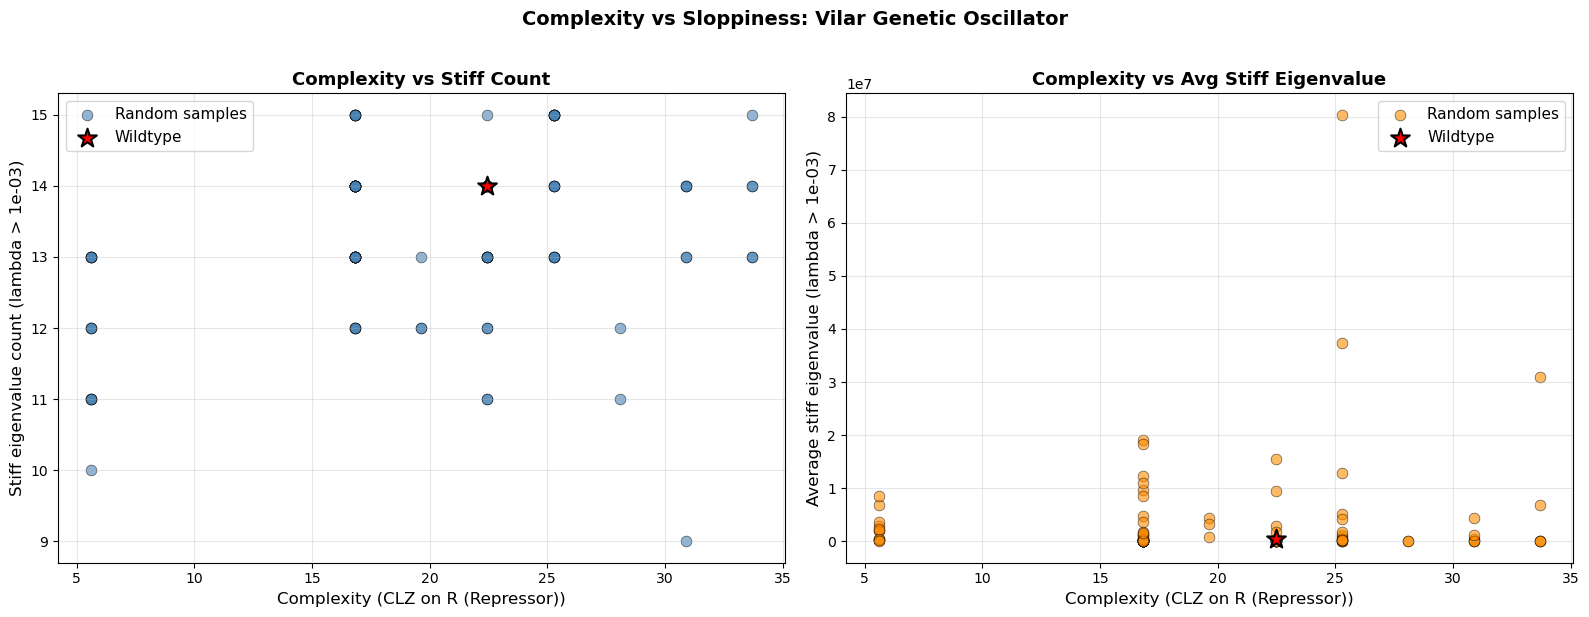


Statistics (101 valid samples):
  Complexity range: [5.61, 33.69]
  Mean complexity: 19.71 +/- 7.31
  Stiff count range: [9, 15]
  Mean stiff count: 13.30 +/- 1.22
  Pearson correlation: 0.300


In [ ]:
# === VISUALIZATION: COMPLEXITY vs STIFFNESS SCATTER ===

if len(results) == 0:
    print("No valid results to plot.")
else:
    complexities = np.array([r['complexity'] for r in results])
    stiff_counts = np.array([r['stiff_count'] for r in results])
    
    # Average stiff eigenvalue
    avg_stiff_eigenvals = []
    for r in results:
        eigvals = r['eigenvalues']
        stiff_eigvals = eigvals[eigvals > STIFF_THRESHOLD]
        avg_stiff_eigenvals.append(np.mean(stiff_eigvals) if len(stiff_eigvals) > 0 else 0.0)
    avg_stiff_eigenvals = np.array(avg_stiff_eigenvals)
    
    is_wt = np.array([r['label'] == 'Wildtype' for r in results])
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    
    # LEFT: Stiff count
    ax1.scatter(complexities[~is_wt], stiff_counts[~is_wt],
                alpha=0.6, s=60, c='steelblue', edgecolors='black', linewidths=0.5,
                label='Random samples')
    if np.any(is_wt):
        ax1.scatter(complexities[is_wt], stiff_counts[is_wt],
                    alpha=1.0, s=200, c='red', marker='*', edgecolors='black', linewidths=1.5,
                    label='Wildtype', zorder=5)
    ax1.set_xlabel(f'Complexity (CLZ on {OBSERVABLE_NAME})', fontsize=12)
    ax1.set_ylabel(f'Stiff eigenvalue count (lambda > {STIFF_THRESHOLD:.0e})', fontsize=12)
    ax1.set_title('Complexity vs Stiff Count', fontsize=13, weight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3)
    
    # RIGHT: Average stiff eigenvalue
    ax2.scatter(complexities[~is_wt], avg_stiff_eigenvals[~is_wt],
                alpha=0.6, s=60, c='darkorange', edgecolors='black', linewidths=0.5,
                label='Random samples')
    if np.any(is_wt):
        ax2.scatter(complexities[is_wt], avg_stiff_eigenvals[is_wt],
                    alpha=1.0, s=200, c='red', marker='*', edgecolors='black', linewidths=1.5,
                    label='Wildtype', zorder=5)
    ax2.set_xlabel(f'Complexity (CLZ on {OBSERVABLE_NAME})', fontsize=12)
    ax2.set_ylabel(f'Average stiff eigenvalue (lambda > {STIFF_THRESHOLD:.0e})', fontsize=12)
    ax2.set_title('Complexity vs Avg Stiff Eigenvalue', fontsize=13, weight='bold')
    ax2.legend(fontsize=11)
    ax2.grid(True, alpha=0.3)
    
    plt.suptitle('Complexity vs Sloppiness: Vilar Genetic Oscillator',
                 y=1.02, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
    
    # Statistics
    print(f"\nStatistics ({len(results)} valid samples):")
    print(f"  Complexity range: [{complexities.min():.2f}, {complexities.max():.2f}]")
    print(f"  Mean complexity: {complexities.mean():.2f} +/- {complexities.std():.2f}")
    print(f"  Stiff count range: [{stiff_counts.min()}, {stiff_counts.max()}]")
    print(f"  Mean stiff count: {stiff_counts.mean():.2f} +/- {stiff_counts.std():.2f}")
    if len(complexities) > 2:
        corr = np.corrcoef(complexities, stiff_counts)[0, 1]
        print(f"  Pearson correlation: {corr:.3f}")

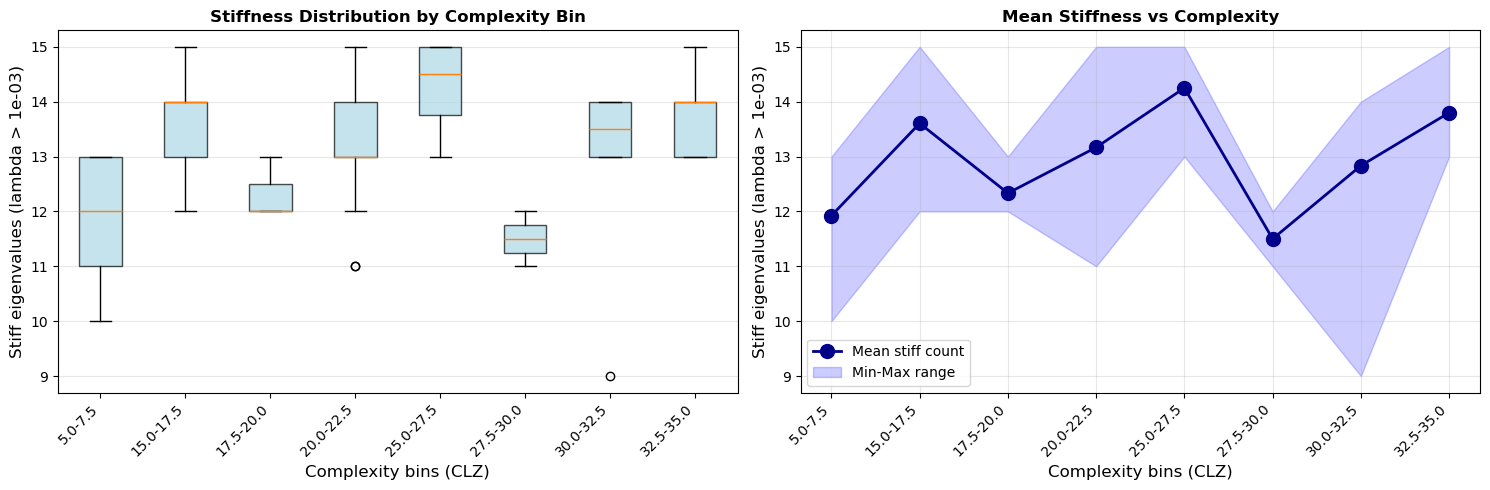


Binned statistics:
  5.0-7.5: mean=11.92, std=1.00, median=12.0, n=13
  15.0-17.5: mean=13.61, std=0.87, median=14.0, n=38
  17.5-20.0: mean=12.33, std=0.47, median=12.0, n=3
  20.0-22.5: mean=13.17, std=1.07, median=13.0, n=18
  25.0-27.5: mean=14.25, std=0.83, median=14.5, n=16
  27.5-30.0: mean=11.50, std=0.50, median=11.5, n=2
  30.0-32.5: mean=12.83, std=1.77, median=13.5, n=6
  32.5-35.0: mean=13.80, std=0.75, median=14.0, n=5


In [ ]:
# === VISUALIZATION: BINNED ANALYSIS ===

if len(results) < 5:
    print("Not enough samples for binned analysis.")
else:
    complexities = np.array([r['complexity'] for r in results])
    stiff_counts = np.array([r['stiff_count'] for r in results])
    
    c_min, c_max = complexities.min(), complexities.max()
    bin_width = 2.5
    bin_edges = np.arange(np.floor(c_min), np.ceil(c_max) + bin_width, bin_width)
    if len(bin_edges) < 3:
        bin_edges = np.linspace(c_min, c_max, 5)
    
    bin_labels = [f"{bin_edges[i]:.1f}-{bin_edges[i+1]:.1f}" for i in range(len(bin_edges) - 1)]
    bin_indices = np.digitize(complexities, bin_edges) - 1
    
    binned_counts = []
    binned_labels = []
    bin_means = []
    
    for b in range(len(bin_labels)):
        mask = bin_indices == b
        if np.any(mask):
            binned_counts.append(stiff_counts[mask])
            binned_labels.append(bin_labels[b])
            bin_means.append(np.mean(stiff_counts[mask]))
    
    if len(binned_counts) == 0:
        print("No samples fell into any bin.")
    else:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
        
        bp = ax1.boxplot(binned_counts, labels=binned_labels,
                         patch_artist=True, showfliers=True)
        for patch in bp['boxes']:
            patch.set_facecolor('lightblue')
            patch.set_alpha(0.7)
        ax1.set_xticklabels(binned_labels, rotation=45, ha='right')
        ax1.set_xlabel('Complexity bins (CLZ)', fontsize=12)
        ax1.set_ylabel(f'Stiff eigenvalues (lambda > {STIFF_THRESHOLD:.0e})', fontsize=12)
        ax1.set_title('Stiffness Distribution by Complexity Bin', fontsize=12, weight='bold')
        ax1.grid(True, axis='y', alpha=0.3)
        
        ax2.plot(range(len(bin_means)), bin_means, 'o-', markersize=10,
                linewidth=2, color='darkblue', label='Mean stiff count')
        ax2.fill_between(range(len(bin_means)),
                         [np.min(bc) for bc in binned_counts],
                         [np.max(bc) for bc in binned_counts],
                         alpha=0.2, color='blue', label='Min-Max range')
        ax2.set_xticks(range(len(binned_labels)))
        ax2.set_xticklabels(binned_labels, rotation=45, ha='right')
        ax2.set_xlabel('Complexity bins (CLZ)', fontsize=12)
        ax2.set_ylabel(f'Stiff eigenvalues (lambda > {STIFF_THRESHOLD:.0e})', fontsize=12)
        ax2.set_title('Mean Stiffness vs Complexity', fontsize=12, weight='bold')
        ax2.legend(fontsize=10)
        ax2.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        print("\nBinned statistics:")
        for label, vals in zip(binned_labels, binned_counts):
            print(f"  {label}: mean={np.mean(vals):.2f}, std={np.std(vals):.2f}, "
                  f"median={np.median(vals):.1f}, n={len(vals)}")

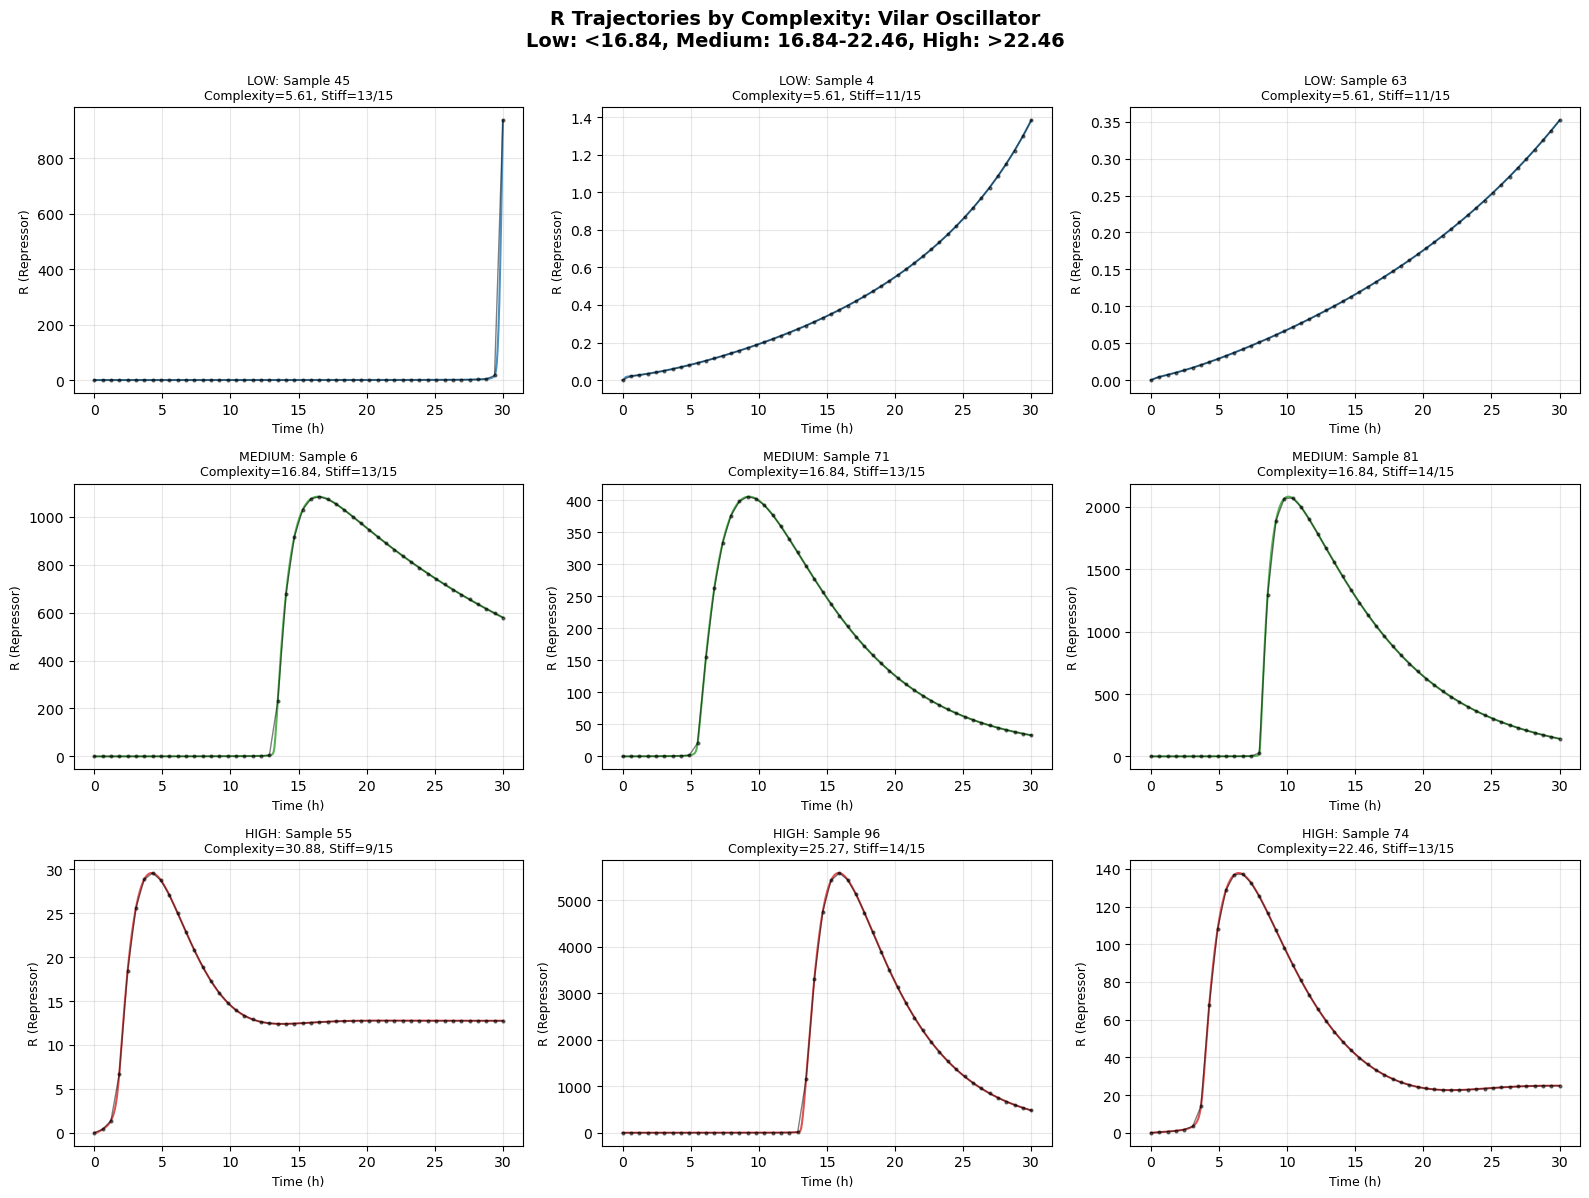

In [ ]:
# === VISUALIZATION: C TRAJECTORIES BY COMPLEXITY ===

if len(results) < 9:
    print("Not enough samples for low/medium/high complexity analysis.")
else:
    complexities = np.array([r['complexity'] for r in results])
    
    c_low_threshold = np.percentile(complexities, 33)
    c_high_threshold = np.percentile(complexities, 67)
    
    low_indices = np.where(complexities < c_low_threshold)[0]
    mid_indices = np.where((complexities >= c_low_threshold) & (complexities < c_high_threshold))[0]
    high_indices = np.where(complexities >= c_high_threshold)[0]
    
    n_per_bin = 3
    rng = np.random.default_rng(42)
    selected_low = rng.choice(low_indices, min(n_per_bin, len(low_indices)), replace=False)
    selected_mid = rng.choice(mid_indices, min(n_per_bin, len(mid_indices)), replace=False)
    selected_high = rng.choice(high_indices, min(n_per_bin, len(high_indices)), replace=False)
    
    fig, axes = plt.subplots(3, 3, figsize=(16, 12))
    
    for row, (selected, regime, color) in enumerate([
        (selected_low, 'LOW', 'C0'),
        (selected_mid, 'MEDIUM', 'C2'),
        (selected_high, 'HIGH', 'C3')
    ]):
        for col, idx in enumerate(selected):
            entry = results[idx]
            p_sample = entry['params']
            
            t, states = simulate_vilar(p_sample, y0, (0, SIM_TIME), SIM_POINTS)
            
            if t is not None and states is not None:
                R_signal = states[OBSERVABLE_IDX, :]
                
                coarse_time, coarse_signal = coarse_grain(t, R_signal, COARSE_BINS)
                encoding = up_down_encoding(coarse_time, coarse_signal)
                
                ax = axes[row, col]
                ax.plot(t, R_signal, linewidth=1.5, color=color, alpha=0.8)
                ax.plot(coarse_time, coarse_signal, 'ko-', markersize=2,
                        linewidth=1, alpha=0.5, label='Coarse')
                
                ax.set_title(f"{regime}: {entry['label']}\n"
                             f"Complexity={entry['complexity']:.2f}, "
                             f"Stiff={entry['stiff_count']}/{P}",
                             fontsize=9)
                ax.set_xlabel('Time (h)', fontsize=9)
                ax.set_ylabel(OBSERVABLE_NAME, fontsize=9)
                ax.grid(True, alpha=0.3)
    
    plt.suptitle(f'C Trajectories by Complexity: Vilar Oscillator\n'
                 f'Low: <{c_low_threshold:.2f}, Medium: {c_low_threshold:.2f}-{c_high_threshold:.2f}, '
                 f'High: >{c_high_threshold:.2f}',
                 y=0.995, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()


PERFORMANCE BOTTLENECK ANALYSIS

Complexity computation (simulation + CLZ):
  Mean: 0.370s
  Total: 37.0s (12.4%)

Hessian computation (sensitivity ODEs, 144 augmented vars):
  Mean: 2.619s
  Total: 261.9s (87.6%)

Hessian / Complexity ratio: 7.07x
  -> BOTTLENECK: Hessian computation is the limiting factor


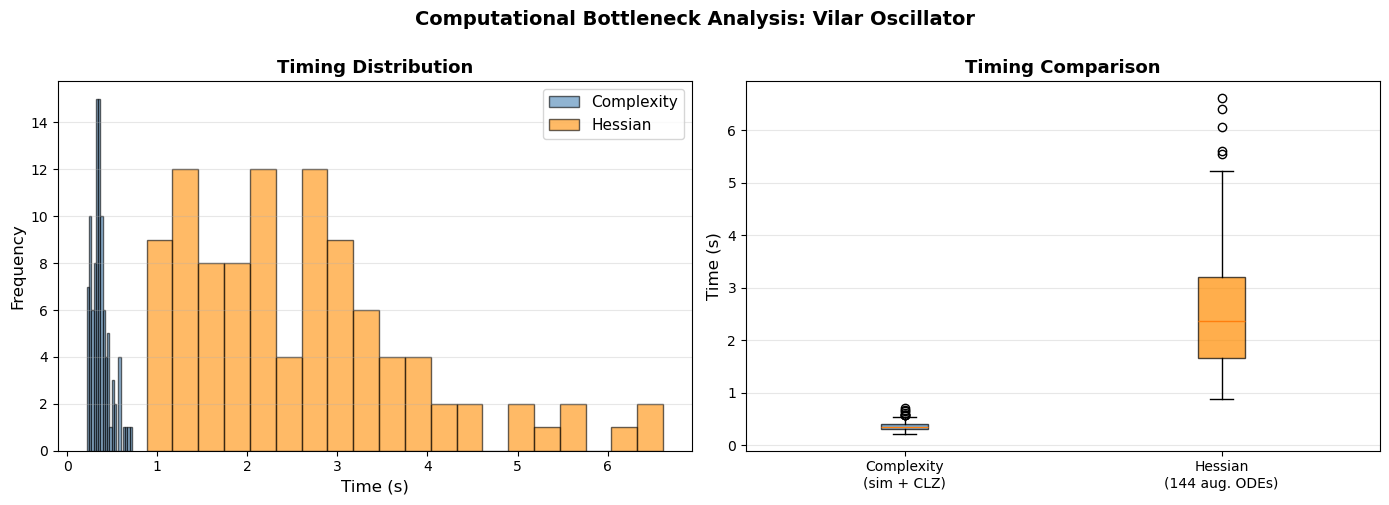

In [ ]:
# === PERFORMANCE ANALYSIS ===

if len(timing_complexity) > 0 and len(timing_hessian) > 0:
    timing_complexity = np.array(timing_complexity)
    timing_hessian = np.array(timing_hessian)
    
    print("\n" + "=" * 70)
    print("PERFORMANCE BOTTLENECK ANALYSIS")
    print("=" * 70)
    
    print(f"\nComplexity computation (simulation + CLZ):")
    print(f"  Mean: {timing_complexity.mean():.3f}s")
    print(f"  Total: {timing_complexity.sum():.1f}s "
          f"({100*timing_complexity.sum()/(timing_complexity.sum()+timing_hessian.sum()):.1f}%)")
    
    print(f"\nHessian computation (sensitivity ODEs, {N_STATES + N_STATES*P} augmented vars):")
    print(f"  Mean: {timing_hessian.mean():.3f}s")
    print(f"  Total: {timing_hessian.sum():.1f}s "
          f"({100*timing_hessian.sum()/(timing_complexity.sum()+timing_hessian.sum()):.1f}%)")
    
    ratio = timing_hessian.mean() / timing_complexity.mean()
    print(f"\nHessian / Complexity ratio: {ratio:.2f}x")
    if ratio > 2:
        print("  -> BOTTLENECK: Hessian computation is the limiting factor")
    elif ratio < 0.5:
        print("  -> BOTTLENECK: Complexity simulation is the limiting factor")
    else:
        print("  -> Balanced: Both steps take similar time")
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1.hist(timing_complexity, bins=20, alpha=0.6, label='Complexity', color='steelblue', edgecolor='black')
    ax1.hist(timing_hessian, bins=20, alpha=0.6, label='Hessian', color='darkorange', edgecolor='black')
    ax1.set_xlabel('Time (s)', fontsize=12)
    ax1.set_ylabel('Frequency', fontsize=12)
    ax1.set_title('Timing Distribution', fontsize=13, weight='bold')
    ax1.legend(fontsize=11)
    ax1.grid(True, alpha=0.3, axis='y')
    
    bp = ax2.boxplot([timing_complexity, timing_hessian],
                     labels=['Complexity\n(sim + CLZ)', f'Hessian\n({N_STATES+N_STATES*P} aug. ODEs)'],
                     patch_artist=True, showfliers=True)
    bp['boxes'][0].set_facecolor('steelblue')
    bp['boxes'][1].set_facecolor('darkorange')
    for patch in bp['boxes']:
        patch.set_alpha(0.7)
    ax2.set_ylabel('Time (s)', fontsize=12)
    ax2.set_title('Timing Comparison', fontsize=13, weight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle('Computational Bottleneck Analysis: Vilar Oscillator',
                 y=1.00, fontsize=14, weight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("No timing data available.")

In [ ]:
# === SUMMARY ===

print("\n" + "=" * 70)
print("VILAR SLOPPY COMPLEXITY ANALYSIS - SUMMARY")
print("=" * 70)
print(f"\nModel: Vilar et al. (2002) Genetic Oscillator")
print(f"  States: {N_STATES} (DA, DAp, DR, DRp, MA, MR, A, R, C)")
print(f"  Parameters: {P} (all kinetic rates)")
print(f"  Observable: {OBSERVABLE_NAME}")
print(f"  Augmented system for Hessian: {N_STATES + N_STATES*P} ODEs")
print(f"\nSampling:")
print(f"  {N_SAMPLES} attempted, {len(results)} valid")
print(f"  Failed complexity: {failed_complexity}")
print(f"  Failed sloppiness: {failed_sloppiness}")

if len(results) > 0:
    complexities = np.array([r['complexity'] for r in results])
    stiff_counts = np.array([r['stiff_count'] for r in results])
    
    print(f"\nComplexity (CLZ):")
    print(f"  Range: [{complexities.min():.2f}, {complexities.max():.2f}]")
    print(f"  Mean:  {complexities.mean():.2f} +/- {complexities.std():.2f}")
    print(f"\nSloppiness (stiff eigenvalue count, threshold={STIFF_THRESHOLD:.0e}):")
    print(f"  Range: [{stiff_counts.min()}, {stiff_counts.max()}] out of {P}")
    print(f"  Mean:  {stiff_counts.mean():.2f} +/- {stiff_counts.std():.2f}")
    
    if len(complexities) > 2:
        corr = np.corrcoef(complexities, stiff_counts)[0, 1]
        print(f"\nCorrelation (complexity vs stiff count): r = {corr:.3f}")
    
    # Wildtype info
    wt_entries = [r for r in results if r['label'] == 'Wildtype']
    if wt_entries:
        wt = wt_entries[0]
        print(f"\nWildtype:")
        print(f"  Complexity: {wt['complexity']:.3f}")
        print(f"  Stiff count: {wt['stiff_count']}/{P}")
        print(f"  Eigenvalue range: [{wt['eigenvalues'][-1]:.2e}, {wt['eigenvalues'][0]:.2e}]")

print(f"\n{'='*70}")
print("VilarSloppyComplexity analysis complete!")
print(f"{'='*70}")


VILAR SLOPPY COMPLEXITY ANALYSIS - SUMMARY

Model: Vilar et al. (2002) Genetic Oscillator
  States: 9 (DA, DAp, DR, DRp, MA, MR, A, R, C)
  Parameters: 15 (all kinetic rates)
  Observable: R (Repressor)
  Augmented system for Hessian: 144 ODEs

Sampling:
  100 attempted, 101 valid
  Failed complexity: 0
  Failed sloppiness: 0

Complexity (CLZ):
  Range: [5.61, 33.69]
  Mean:  19.71 +/- 7.31

Sloppiness (stiff eigenvalue count, threshold=1e-03):
  Range: [9, 15] out of 15
  Mean:  13.30 +/- 1.22

Correlation (complexity vs stiff count): r = 0.300

Wildtype:
  Complexity: 22.459
  Stiff count: 14/15
  Eigenvalue range: [9.55e-04, 3.88e+06]

VilarSloppyComplexity analysis complete!
